# Pure MFACO (giant tour + split) for CVRP — Performance Test (no model residual)

This notebook benchmarks **pure MFACO** on randomly-generated Euclidean CVRP instances using your C++/pybind11 module `faco_cvrp` (class `MFACO_CVRP`).

**What you’ll get:**
- Generate CVRP instances (coords + demands, normalized capacity)
- Run MFACO for `n_iterations` with **no residual logits**
- Track best cost over time + runtime statistics
- Optional small parameter sweep (ants / iterations / k / min_new_edges)

> Assumptions:
> - Node `0` is the depot.
> - `demand[0] = 0`.
> - Your `faco_cvrp` extension is installed and exposes `MFACO_CVRP`.


In [1]:
import time
import math
import numpy as np
import torch
from utils import gen_instance_for_mfaco

# Plotting
import matplotlib.pyplot as plt

# Import your compiled extension
try:
    import faco_cvrp
except Exception as e:
    raise RuntimeError(
        "Could not import faco_cvrp. Make sure your extension is built/installed.\n"
        "Example (from repo root):\n"
        "  uv pip install --no-build-isolation -e .\n"
        "or\n"
        "  python -m pip install -e .\n"
        f"\nOriginal error: {e}"
    )

print("faco_cvrp imported. OpenMP max threads:", faco_cvrp.get_max_threads())


faco_cvrp imported. OpenMP max threads: 10


## 1) CVRP instance generator

We generate:
- Random coordinates in `[0,1]^2`
- Demands normalized so that `capacity = 1.0`
- A target expected number of customers per route (controls tightness)

You can replace this with reading benchmark instances later if you want.


In [2]:
def euclidean_route_cost(route0, coords):
    """route0 is like [0, ..., 0, ..., 0]"""
    xy = coords[route0]
    d = np.sqrt(((xy[1:] - xy[:-1]) ** 2).sum(axis=1))
    return float(d.sum())


## 2) MFACO runner (pure MFACO: residual_logits=None)

We explicitly do the loop in Python to keep the benchmark transparent:
- `sample(require_prob=False, residual_logits=None)`
- pick best ant of this iteration
- `_update_pheromone_from_perm(best_perm, best_cost)`

If your C++ already wraps the whole loop, you can benchmark that too — this version isolates the MFACO sampling performance.


In [3]:
def run_mfaco_cvrp(
    coords: np.ndarray,
    demand: np.ndarray,
    capacity: float = 1.0,
    n_ants: int = 64,
    n_iterations: int = 300,
    cand_list_size: int = 32,
    backup_list_size: int = 32,
    min_new_edges: int = 8,
    decay: float = 0.9,
    alpha: float = 1.0,
    p_best: float = 0.05,
    use_local_search: bool = True,
    disable_heuristic: bool = False,
    omp_threads: int | None = None,
    seed: int = 0,
    return_best_decoded: bool = True,
    verbose_every: int = 50,
):
    if omp_threads is not None:
        faco_cvrp.set_num_threads(int(omp_threads))

    # build solver
    solver = faco_cvrp.MFACO_CVRP(
        coords.astype(np.float32, copy=False),
        demand.astype(np.float32, copy=False),
        float(capacity),
        int(n_ants),
        int(cand_list_size),
        int(backup_list_size),
        int(min_new_edges),
        float(decay),
        float(alpha),
        float(p_best),
        bool(use_local_search),
        bool(disable_heuristic),
    )
    solver.seed_rng(int(seed))

    best_cost = float("inf")
    best_perm = None
    best_decoded = None

    hist_best = []
    hist_iter_time = []

    t0 = time.perf_counter()
    for it in range(1, n_iterations + 1):
        t_it0 = time.perf_counter()

        costs, perms, decoded, _traces = solver.sample(
            False,             # require_prob
            None,              # residual_logits (pure MFACO)
            False,             # parallel_traced
            return_best_decoded  # return_decoded
        )

        # costs is a numpy array (n_ants,)
        costs_np = np.asarray(costs, dtype=np.float32)
        i_best = int(costs_np.argmin())
        c_best = float(costs_np[i_best])

        if c_best < best_cost:
            best_cost = c_best
            best_perm = np.asarray(perms[i_best], dtype=np.int32).copy()
            if return_best_decoded and decoded is not None:
                best_decoded = np.asarray(decoded[i_best], dtype=np.int32).copy()

        # Update pheromone using best-of-iteration (elitist-style update)
        # best_perm expected length >= m
        solver._update_pheromone_from_perm(best_perm, float(best_cost))

        t_it1 = time.perf_counter()
        hist_iter_time.append(t_it1 - t_it0)
        hist_best.append(best_cost)

        if verbose_every and (it % verbose_every == 0 or it == 1):
            print(f"iter {it:4d} | best_cost {best_cost:.6f} | iter_time {hist_iter_time[-1]*1000:.2f} ms")

    total_time = time.perf_counter() - t0
    info = {
        "best_cost": best_cost,
        "total_time_sec": total_time,
        "avg_iter_ms": 1000.0 * float(np.mean(hist_iter_time)) if hist_iter_time else None,
        "median_iter_ms": 1000.0 * float(np.median(hist_iter_time)) if hist_iter_time else None,
        "omp_threads": omp_threads,
        "n_ants": n_ants,
        "n_iterations": n_iterations,
        "cand_list_size": cand_list_size,
        "backup_list_size": backup_list_size,
        "min_new_edges": min_new_edges,
        "use_local_search": use_local_search,
    }

    return {
        "solver": solver,
        "best_cost": best_cost,
        "best_perm": best_perm,
        "best_decoded": best_decoded,
        "hist_best": np.array(hist_best, dtype=np.float32),
        "hist_iter_time": np.array(hist_iter_time, dtype=np.float32),
        "info": info,
    }


## 3) Single-run benchmark

Adjust the knobs below:
- `n_customers`: problem size
- `expected_customers_per_route`: controls capacity tightness
- `n_ants`, `n_iterations`, `min_new_edges`, `cand_list_size`
- `use_local_search`: this is your MFACO-style restricted 2-opt on the **giant tour** (not VRP-route 2-opt)


In [11]:
# Instance
n_customers = 500
instance_seed = 123

coords, demand, capacity = gen_instance_for_mfaco(
    n=n_customers,
    device='cpu',
)

print(coords, demand, capacity)

# Run
run = run_mfaco_cvrp(
    coords=coords.numpy(),
    demand=demand.numpy(),
    capacity=capacity,
    n_ants=128,
    n_iterations=1000,
    cand_list_size=32,
    backup_list_size=64,
    min_new_edges=8,
    decay=0.1,
    alpha=1.0,
    p_best=0.05,
    use_local_search=True,
    disable_heuristic=False,
    omp_threads=None,   # set e.g. 8
    seed=42,
    return_best_decoded=True,
    verbose_every=50,
)

run["info"], run["best_cost"]


Loaded ../data/cvrp/testDataset-500.pt | idx=0 | demand (501,) | dist (501, 501)
tensor([[-0.0178,  0.0244],
        [ 0.2606,  0.1690],
        [-0.2306,  0.0519],
        ...,
        [-0.1445,  0.1713],
        [-0.1015, -0.4180],
        [ 0.5685,  0.0346]]) tensor([0., 9., 7., 4., 4., 3., 6., 1., 6., 9., 4., 7., 9., 2., 3., 8., 6., 8.,
        4., 5., 3., 2., 4., 3., 1., 2., 9., 4., 3., 9., 2., 4., 4., 4., 3., 4.,
        8., 7., 3., 8., 7., 6., 9., 2., 4., 6., 6., 6., 9., 6., 5., 7., 3., 1.,
        4., 9., 8., 2., 1., 5., 4., 7., 7., 9., 8., 1., 7., 6., 9., 1., 9., 2.,
        7., 9., 9., 1., 2., 1., 3., 8., 1., 6., 9., 6., 7., 9., 6., 4., 2., 1.,
        4., 9., 3., 8., 3., 2., 2., 5., 5., 8., 3., 3., 3., 3., 7., 5., 4., 9.,
        4., 8., 7., 6., 8., 9., 4., 5., 9., 9., 9., 5., 7., 8., 3., 7., 6., 9.,
        3., 6., 9., 4., 5., 6., 4., 9., 2., 1., 8., 2., 5., 3., 9., 4., 4., 3.,
        8., 5., 3., 5., 6., 7., 3., 6., 2., 7., 8., 5., 4., 8., 3., 4., 7., 8.,
        7., 5., 4

Loaded ../data/cvrp/testDataset-500.pt | idx=0 | demand (501,) | dist (501, 501)
tensor([[-0.0178,  0.0244],
        [ 0.2606,  0.1690],
        [-0.2306,  0.0519],
        ...,
        [-0.1445,  0.1713],
        [-0.1015, -0.4180],
        [ 0.5685,  0.0346]]) tensor([0., 9., 7., 4., 4., 3., 6., 1., 6., 9., 4., 7., 9., 2., 3., 8., 6., 8.,
        4., 5., 3., 2., 4., 3., 1., 2., 9., 4., 3., 9., 2., 4., 4., 4., 3., 4.,
        8., 7., 3., 8., 7., 6., 9., 2., 4., 6., 6., 6., 9., 6., 5., 7., 3., 1.,
        4., 9., 8., 2., 1., 5., 4., 7., 7., 9., 8., 1., 7., 6., 9., 1., 9., 2.,
        7., 9., 9., 1., 2., 1., 3., 8., 1., 6., 9., 6., 7., 9., 6., 4., 2., 1.,
        4., 9., 3., 8., 3., 2., 2., 5., 5., 8., 3., 3., 3., 3., 7., 5., 4., 9.,
        4., 8., 7., 6., 8., 9., 4., 5., 9., 9., 9., 5., 7., 8., 3., 7., 6., 9.,
        3., 6., 9., 4., 5., 6., 4., 9., 2., 1., 8., 2., 5., 3., 9., 4., 4., 3.,
        8., 5., 3., 5., 6., 7., 3., 6., 2., 7., 8., 5., 4., 8., 3., 4., 7., 8.,
        7., 5., 4

({'best_cost': 53.936683654785156,
  'total_time_sec': 12.021629194000525,
  'avg_iter_ms': 12.016793249003058,
  'median_iter_ms': 11.415043999932095,
  'omp_threads': None,
  'n_ants': 128,
  'n_iterations': 1000,
  'cand_list_size': 32,
  'backup_list_size': 64,
  'min_new_edges': 8,
  'use_local_search': True},
 53.936683654785156)

In [5]:
# Sanity check decoded route cost (only if you enabled return_best_decoded)
if run["best_decoded"] is not None:
    decoded = run["best_decoded"]
    py_cost = euclidean_route_cost(decoded, coords)
    print("C++ reported best_cost:", run["best_cost"])
    print("Python recomputed cost:", py_cost)
    print("Abs diff:", abs(py_cost - run["best_cost"]))
else:
    print("No decoded route returned.")


C++ reported best_cost: 51.29423904418945
Python recomputed cost: 51.29424285888672
Abs diff: 3.814697265625e-06


/tmp/ipykernel_28108/570223226.py:4: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  d = np.sqrt(((xy[1:] - xy[:-1]) ** 2).sum(axis=1))


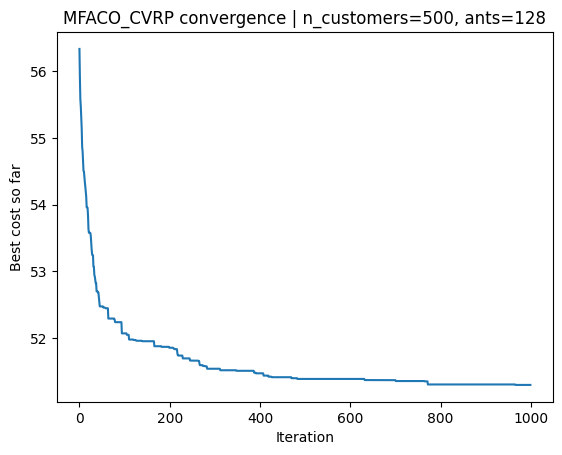

Total time: 11.885 s
Avg iter:   11.881 ms
Median iter:11.239 ms


In [6]:
# Plot convergence
hist = run["hist_best"]
plt.figure()
plt.plot(hist)
plt.xlabel("Iteration")
plt.ylabel("Best cost so far")
plt.title(f"MFACO_CVRP convergence | n_customers={n_customers}, ants={run['info']['n_ants']}")
plt.show()

# Iter timing stats
tms = run["hist_iter_time"] * 1000.0
print(f"Total time: {run['info']['total_time_sec']:.3f} s")
print(f"Avg iter:   {tms.mean():.3f} ms")
print(f"Median iter:{np.median(tms):.3f} ms")


In [10]:
import numpy as np
import hygese as hgs
import torch

def solve_with_hgs(all_locations, all_demands, capacity, time_limit=2.0, seed=1, verbose=False):
    loc = all_locations.detach().cpu().numpy()
    dem = all_demands.detach().cpu().numpy()

    S = 1000  # scale to integers
    dem_i = np.rint(dem * S).astype(int)
    cap_i = int(np.rint(capacity * S))
    x = loc[:, 0] * S
    y = loc[:, 1] * S

    # HGS-CVRP is a fixed-vehicle CVRP solver, so you must provide num_vehicles.
    # A common fair choice is the minimum required by capacity:
    num_vehicles = int(np.ceil(dem_i.sum() / max(1, cap_i)))

    data = {
        "x_coordinates": x,
        "y_coordinates": y,
        "demands": dem_i,
        "service_times": np.zeros(len(dem_i)),
        "vehicle_capacity": cap_i,
        "num_vehicles": num_vehicles,
        "depot": 0,
    }

    ap = hgs.AlgorithmParameters(timeLimit=float(time_limit), seed=int(seed))
    solver = hgs.Solver(parameters=ap, verbose=bool(verbose))
    result = solver.solve_cvrp(data)

    # NOTE: result.routes does NOT include depot; all routes implicitly start/end at depot. :contentReference[oaicite:4]{index=4}
    return result.cost / S, result.routes

print(demand)
cost, routes = solve_with_hgs(coords, demand, capacity=250, time_limit=10.0, seed=1)
# verify routes actually satisfy capacity and demands
# also verify every customers is visited exactly once
visited = set()
cost = 0
prev = 0
for r in routes:
    route_demand = 0
    for customer in r:
        if customer in visited:
            raise ValueError(f"Customer {customer} visited multiple times")
        visited.add(customer)
        route_demand += demand[customer].item()
        cost += torch.norm(coords[prev] - coords[customer], p=2).item()
        prev = customer
    assert route_demand <= 250 + 1e-5, f"Route demand {route_demand} exceeds capacity"
    print(route_demand)
assert len(visited) == len(demand) - 1, f"Not all customers visited, visited {len(visited)}, expected {len(demand)-1}"

print(len(routes))

tensor([0, 8, 5, 6, 5, 1, 5, 2, 9, 8, 1, 6, 8, 4, 7, 9, 7, 6, 9, 7, 5, 2, 3, 8,
        5, 7, 8, 3, 1, 5, 1, 7, 7, 4, 2, 8, 2, 7, 6, 3, 2, 3, 6, 2, 3, 9, 9, 1,
        9, 6, 4, 4, 8, 6, 2, 2, 2, 6, 7, 2, 4, 4, 8, 4, 6, 4, 7, 9, 1, 2, 3, 3,
        5, 9, 6, 6, 9, 4, 6, 2, 7, 5, 2, 5, 8, 7, 1, 9, 1, 1, 7, 4, 8, 2, 6, 8,
        6, 4, 4, 1, 3, 2, 4, 3, 8, 8, 1, 1, 1, 8, 6, 5, 4, 5, 6, 7, 5, 7, 4, 2,
        4, 4, 3, 1, 7, 1, 6, 3, 5, 1, 8, 4, 1, 9, 3, 2, 7, 4, 9, 4, 2, 9, 5, 5,
        8, 4, 5, 1, 5, 1, 5, 3, 2, 6, 1, 1, 3, 3, 1, 3, 8, 3, 4, 5, 4, 9, 6, 4,
        2, 5, 7, 8, 2, 6, 5, 2, 1, 3, 8, 3, 5, 7, 8, 5, 3, 4, 1, 6, 5, 4, 4, 5,
        9, 9, 9, 4, 2, 7, 6, 6, 5, 2, 9, 8, 8, 9, 5, 5, 4, 9, 2, 1, 8, 6, 4, 9,
        6, 2, 5, 4, 5, 3, 3, 8, 6, 5, 7, 2, 5, 4, 1, 9, 5, 2, 2, 9, 9, 8, 2, 5,
        3, 8, 8, 1, 1, 5, 3, 1, 9, 1, 4, 7, 5, 1, 5, 4, 7, 1, 1, 2, 1, 3, 6, 6,
        7, 1, 3, 2, 2, 5, 5, 8, 7, 5, 8, 4, 7, 2, 6, 7, 6, 4, 5, 1, 1, 4, 3, 6,
        6, 6, 4, 1, 1, 1, 3, 3, 9, 3, 5,

## 4) (Optional) Small parameter sweep

This runs a few configs and prints a compact summary.
Keep it small unless you really want a long benchmark.


In [8]:
def sweep_configs(coords, demand, capacity, base_seed=0):
    configs = [
        dict(n_ants=32, min_new_edges=6, cand_list_size=24, use_local_search=False),
        dict(n_ants=32, min_new_edges=6, cand_list_size=24, use_local_search=True),
        dict(n_ants=64, min_new_edges=8, cand_list_size=32, use_local_search=False),
        dict(n_ants=64, min_new_edges=8, cand_list_size=32, use_local_search=True),
    ]
    results = []
    for i, cfg in enumerate(configs):
        print("\n===", cfg, "===")
        run = run_mfaco_cvrp(
            coords=coords,
            demand=demand,
            capacity=capacity,
            n_iterations=200,
            backup_list_size=32,
            decay=0.9,
            alpha=1.0,
            p_best=0.05,
            disable_heuristic=False,
            omp_threads=None,
            seed=base_seed + i,
            return_best_decoded=False,
            verbose_every=0,
            **cfg,
        )
        results.append({
            **cfg,
            "best_cost": float(run["best_cost"]),
            "total_time_sec": float(run["info"]["total_time_sec"]),
            "avg_iter_ms": float(run["info"]["avg_iter_ms"]),
        })
    return results

results = sweep_configs(coords, demand, capacity, base_seed=100)
results



=== {'n_ants': 32, 'min_new_edges': 6, 'cand_list_size': 24, 'use_local_search': False} ===


AttributeError: 'Tensor' object has no attribute 'astype'

In [ ]:
# Pretty print sweep
import pandas as pd

df = pd.DataFrame(results)
df = df.sort_values(["best_cost", "total_time_sec"]).reset_index(drop=True)
df


,n_ants,min_new_edges,cand_list_size,use_local_search,best_cost,total_time_sec,avg_iter_ms
0,32,6,24,True,100.270844,0.476628,2.381711
1,64,8,32,True,100.352592,1.045137,5.222801
2,64,8,32,False,104.429146,0.864759,4.321675
3,32,6,24,False,104.798309,0.492377,2.460504


## 5) Notes on interpreting results

- **`use_local_search=True`** uses your restricted 2-opt on the **giant tour**, not directly on decoded routes.
- The **Split DP** can move route boundaries even for small permutation changes.
- If you want “true CVRP local search around changed edges”, the next upgrade is:
  - decode split segments,
  - add boundary customers to the checklist,
  - run intra-route 2-opt / relocate on each segment locally.

But for “pure MFACO baseline”, this notebook gives you clean timing + convergence.
